In [1]:
dataset_path = r"C:\Users\user\.cache\kagglehub\datasets\hasibalmuzdadid\shoe-vs-sandal-vs-boot-dataset-15k-images\versions\2\Shoe vs Sandal vs Boot Dataset"

In [2]:
import os

print(os.listdir(dataset_path))

['Boot', 'Sandal', 'Shoe']


In [3]:
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 12000 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


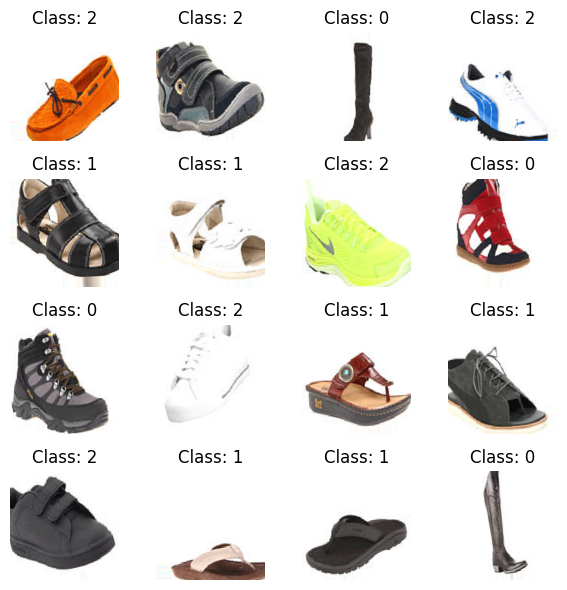

In [5]:
import matplotlib.pyplot as plt

# Get one batch of images
images, labels = next(train_generator)

fig, axes = plt.subplots(4, 4, figsize=(6,6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(f"Class: {labels[i].argmax()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
#The Base Model 
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,227 (56.14 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
#data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    steps_per_epoch=50,      
    validation_steps=10
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 186s 4s/step - accuracy: 0.5288 - loss: 0.9889 - val_accuracy: 0.7750 - val_loss: 0.8921
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.6513 - loss: 0.8629 - val_accuracy: 0.8375 - val_loss: 0.7815
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.7362 - loss: 0.7680 - val_accuracy: 0.8344 - val_loss: 0.6916


In [11]:
test_loss, test_acc = model.evaluate(val_generator, verbose=2)
print(f"Validation Accuracy: {test_acc}")

94/94 - 279s - 3s/step - accuracy: 0.8470 - loss: 0.7032
Validation Accuracy: 0.847000002861023


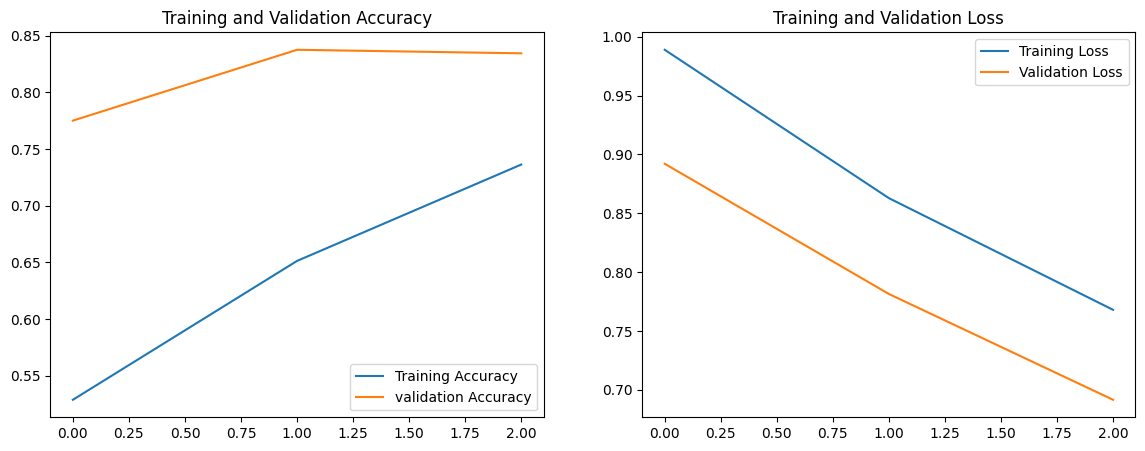

In [12]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./VGG16classwork.png')
plt.show()
